## Excercie chargement des bien-fonds dans PostGIS

## Objectif

Dans cet execrcie, nous allons charger les bien-fonds de la commuene d'Yverdon dans une table de la base PostgreSQL. Les bien-fonds provindrons du service REST de l'ArcGIS server du canton de Vaud. Ils seront téléchargés sous la forme de JSON. 

In [1]:
import os
import requests
import time


## 📥 Récupérer des données du canton de Vaud

Tu viens de finir le cours de programmation 🎉 ? Parfait ! Tu as désormais les compétences pour explorer les données géographiques mises à disposition (officieusement) par le **canton de Vaud**.

🔗 **URL du service REST** :
[https://ags.vd.ch/arcgis/rest/services/OGC/wmsVD/MapServer](https://ags.vd.ch/arcgis/rest/services/OGC/wmsVD/MapServer)

> ⚠️ Attention : ce service n’est **pas officiel**. Il peut être modifié ou supprimé sans préavis. Et il demande un peu de débrouillardise technique 🧑‍💻.


### 🔍 Comment ça fonctionne ?

Ce service REST est fourni par **ArcGIS Server**. Il te donne accès à **plusieurs couches de données géographiques**.

✅ En allant sur l’URL principale, tu verras la **liste complète des couches**.
🆔 Chaque couche a un **identifiant unique**. Par exemple :
➡️ La couche des bien-fonds est accessible ici :
[https://ags.vd.ch/arcgis/rest/services/OGC/wmsVD/MapServer/272](https://ags.vd.ch/arcgis/rest/services/OGC/wmsVD/MapServer/272)

💡 En analysant cette page, tu y trouveras :

* le nom et la description de la couche 📝
* les champs disponibles 📑
* les types de données 📊
* un exemple de requête pour récupérer les données en JSON 📦

> 👀 À noter : la valeur **MaxRecordCount: 1** signifie que le service ne renvoie **qu’un seul enregistrement à la fois**. C’est pratique pour tester… mais pas pour tout télécharger. Il faudra donc **être malin** pour récupérer par exemple **tous les bien-fonds d’Yverdon** 🧠.


### 🧱 Limitations techniques à connaître

Les services du canton de Vaud imposent quelques contraintes :

* 🧩 **1 seul bien-fonds par requête**
* ⏱️ **Timeout** après plusieurs milliers de requêtes
* 🐢 **Limite de requêtes/minute**, ce qui ralentit les gros téléchargements
* 🚫 Des **restrictions par adresse IP** peuvent s’appliquer


### 🌈 Une lueur d’espoir !

Bonne nouvelle : il existe **une exception** à ces limites 🎁
👉 La **récupération des ObjectIDs** des bien-fonds n’est **pas limitée** !

Tu peux donc faire **une seule requête** pour obtenir **tous les ObjectIDs**, ce qui est super utile pour construire des requêtes plus ciblées par la suite.

✅ Dans ce cas, pense à activer :
**"Return IDs Only:" → True** ✅

<img src="images/ids.png" alt="drawing" width="400"/>


### 🛠️ Comment construire une requête ?

En bas de chaque page de couche, clique sur **"Query"**. Tu pourras y personnaliser ta requête :

1. **Filtrer** sur une commune :
   `NO_COM_CANT = 387` (Yverdon-les-Bains) dans le champ **"Where"** 🏙️
2. Dans **"Out Fields"**, mets : `*` pour tout récupérer 📋
3. Choisis le **format "GeoJSON"** 🧾
4. Définis le système de coordonnées de sortie : **2056 (MN95)** 🗺️
5. Pour récupérer uniquement les ObjectIDs :
   coche **"Return Count Only: True"** 🧮


### 🤝 Et maintenant ?

Nous allons discuter ensemble de la solution proposée 🧩, étape par étape, pour bien comprendre comment formuler les requêtes, analyser les réponses, et contourner les limitations.

💡 Chacun·e est invité·e à utiliser des outils d’intelligence artificielle (comme ChatGPT ou d’autres assistants) pour formuler les requêtes, comprendre les erreurs ou encore explorer les formats de réponse. Ces outils peuvent vous faire gagner du temps et vous aider à progresser plus rapidement 🚀.

Alors à toi de jouer ! On en parle ensemble en classe 😊


In [5]:
url_object_ids = "https://ags.vd.ch/arcgis/rest/services/OGC/wmsVD/MapServer/272/query?where=NO_COM_CANT%3D387&text=&objectIds=&time=&timeRelation=esriTimeRelationOverlaps&geometry=&geometryType=esriGeometryEnvelope&inSR=&spatialRel=esriSpatialRelIntersects&distance=&units=esriSRUnit_Meter&relationParam=&outFields=*&returnGeometry=false&returnTrueCurves=false&maxAllowableOffset=&geometryPrecision=&outSR=2056&havingClause=&returnIdsOnly=true&returnCountOnly=false&orderByFields=&groupByFieldsForStatistics=&outStatistics=&returnZ=false&returnM=false&gdbVersion=&historicMoment=&returnDistinctValues=true&resultOffset=&resultRecordCount=&returnExtentOnly=false&sqlFormat=none&datumTransformation=&parameterValues=&rangeValues=&quantizationParameters=&featureEncoding=esriDefault&f=pjson"
response = requests.get(url_object_ids)
object_ids = response.json().get("objectIds")

# Création d'un dictionnaire pour stocker les biens-fonds, il est pour l'instant vide
dict_biens_fonds = dict()

object_ids

[36107372,
 36107500,
 36107762,
 36108669,
 36107779,
 36108035,
 36107660,
 36108829,
 36109381,
 36109382,
 36107667,
 36108183,
 36108451,
 35946981,
 35946896,
 36115365,
 36115366,
 36114439,
 36114718,
 36115257,
 36114991,
 36115266,
 36114735,
 36115275,
 36113670,
 36114084,
 36114488,
 36115421,
 35971429,
 35971704,
 35971212,
 35971600,
 35971368,
 35971074,
 35970708,
 35970868,
 35970872,
 35970887,
 35970889,
 35971162,
 35971034,
 35970772,
 35970797,
 35948856,
 35948614,
 35948541,
 35948798,
 35948674,
 35948431,
 35948436,
 35948699,
 35948461,
 35947955,
 35948238,
 35948376,
 35948380,
 35948120,
 35948139,
 35948166,
 35947890,
 35947912,
 35953633,
 35953757,
 35953781,
 35953569,
 35953844,
 35953846,
 35953127,
 35953276,
 35953398,
 35953401,
 35953016,
 35953438,
 35953061,
 35953237,
 36013743,
 36014777,
 36015035,
 36014015,
 36013498,
 36014919,
 36015064,
 36015116,
 36013508,
 36014036,
 36013127,
 36014693,
 36013137,
 35958211,
 35958087,
 35957839,

In [ ]:
# On itère sur les identifiants d'objets récupérés
for i, object_id in enumerate(object_ids):

    # On vérifie si l'identifiant d'objet est déjà dans le dictionnaire
    if object_id in dict_biens_fonds:
        print(f"Object ID {object_id} already processed, skipping.")
        continue
    # Si l'identifiant n'est pas dans le dictionnaire, on le télécharge
    progress = (i + 1) / len(object_ids) * 100
    print(f"Progress: {i + 1} - {progress:.2f}%")
    url = f"https://ags.vd.ch/arcgis/rest/services/OGC/wmsVD/MapServer/272/query?where=NO_COM_CANT%3D387&text=&objectIds={object_id}&time=&timeRelation=esriTimeRelationOverlaps&geometry=&geometryType=esriGeometryEnvelope&inSR=&spatialRel=esriSpatialRelIntersects&distance=&units=esriSRUnit_Meter&relationParam=&outFields=*&returnGeometry=true&returnTrueCurves=false&maxAllowableOffset=&geometryPrecision=&outSR=2056&havingClause=&returnIdsOnly=false&returnCountOnly=false&orderByFields=&groupByFieldsForStatistics=&outStatistics=&returnZ=false&returnM=false&gdbVersion=&historicMoment=&returnDistinctValues=false&resultOffset=&resultRecordCount=&returnExtentOnly=false&sqlFormat=none&datumTransformation=&parameterValues=&rangeValues=&quantizationParameters=&featureEncoding=esriDefault&f=geojson"
    while True:
        try:
            response = requests.get(url)
            # Si les téléchargements réussi (HTTP 200), on ajoute l'objet au dictionnaire
            if response.status_code == 200:
                data = response.json()
                dict_biens_fonds[object_id] = data["features"][0]
                break # Sortie de la boucle while si le téléchargement est réussi
            else:
                print(f"Error downloading object ID {object_id}: {response.status_code}")
                time.sleep(60)  # Attente de 30 secondes avant de réessayer
        except requests.RequestException as e:
            print(f"Request failed: {e}")
            time.sleep(60)  # Attente de 60 secondes avant de réessayer


Progress: 1 - 0.03%
Progress: 2 - 0.05%
Progress: 3 - 0.08%
Progress: 4 - 0.10%
Progress: 5 - 0.13%
Progress: 6 - 0.15%
Progress: 7 - 0.18%
Progress: 8 - 0.20%
Progress: 9 - 0.23%
Progress: 10 - 0.25%
Progress: 11 - 0.28%
Progress: 12 - 0.30%
Progress: 13 - 0.33%
Progress: 14 - 0.35%
Progress: 15 - 0.38%
Progress: 16 - 0.40%
Progress: 17 - 0.43%
Progress: 18 - 0.45%
Progress: 19 - 0.48%
Progress: 20 - 0.50%
Progress: 21 - 0.53%
Progress: 22 - 0.55%
Progress: 23 - 0.58%
Progress: 24 - 0.60%
Progress: 25 - 0.63%
Progress: 26 - 0.65%
Progress: 27 - 0.68%
Progress: 28 - 0.70%
Progress: 29 - 0.73%
Progress: 30 - 0.75%
Progress: 31 - 0.78%
Progress: 32 - 0.80%
Progress: 33 - 0.83%
Progress: 34 - 0.85%
Progress: 35 - 0.88%
Progress: 36 - 0.90%
Progress: 37 - 0.93%
Progress: 38 - 0.95%
Progress: 39 - 0.98%
Progress: 40 - 1.00%
Progress: 41 - 1.03%
Progress: 42 - 1.06%
Progress: 43 - 1.08%
Progress: 44 - 1.11%
Progress: 45 - 1.13%
Progress: 46 - 1.16%
Progress: 47 - 1.18%
Progress: 48 - 1.21%
P

In [7]:
import geopandas as gpd

# Extraire les features du dictionnaire
features = list(dict_biens_fonds.values())

# Créer un GeoDataFrame à partir des features GeoJSON
gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:2056")

# Sauvegarder le GeoDataFrame en GeoPackage
gdf.to_file("bien_fonds_yverdon.gpkg", layer="bien_fonds", driver="GPKG")

## Connection à la base de données

Nous allons maintenant nous connecter à la base de données à l'aide de psycopg2


Psycopg2 est une bibliothèque Python permettant d'interagir avec une base de données PostgreSQL. Elle est utilisée pour exécuter des requêtes SQL, gérer les transactions et manipuler les données.

Voici quelques fonctionnalités clés de psycopg2 :
- **Connexion à la base de données** : `psycopg2.connect()` permet d'établir une connexion avec une base PostgreSQL.
- **Exécution de requêtes SQL** : Les objets curseurs (`cursor`) permettent d'exécuter des commandes SQL comme `SELECT`, `INSERT`, `UPDATE`, etc.
- **Gestion des transactions** : Les méthodes `commit()` et `rollback()` permettent de valider ou d'annuler les modifications.
- **Sécurité** : Prend en charge les paramètres pour éviter les injections SQL.
- **Support des types PostgreSQL** : Gère les types spécifiques comme `JSON`, `ARRAY`, et `GEOMETRY`.

Documentation officielle : [https://www.psycopg.org/](https://www.psycopg.org/)


In [ ]:
import psycopg2

In [ ]:
# Remplir ici les variable de connection

host = ""
database = "postgres"
user = 'postgres'
password = 'postgres'

In [ ]:
conn = psycopg2.connect(host=host,database=database,user=user,password=password)

## Création des la table dans la base de données

Maintenant que nos données sont contenues dans la variable "input_data", nous devont créer la table "bf" dans la base de données PostgreSQL. 

La table doit contenir les colonnes suivantes :

|Nom de l'attibut   |Type   |
|---|---|
|no_cantonal   |character varying(254)   |
|numero   |character varying(10)   |
|genre   |character varying(254)   |
|geom   |geometry(Polygon,2056)   |


Le code SQL de création doit être nommé "create_table_query"

In [ ]:
create_table_query = """

DROP TABLE if exists public.bf;

CREATE TABLE public.bf
(
    no_cantonal character varying(254),
    numero character varying(10),
    genre character varying(254),
    geom geometry(Polygon,2056)
);

ALTER TABLE public.bf
    OWNER to postgres;

-- Index: commune_geom

DROP INDEX if exists public.bf_geom;

CREATE INDEX bf_geom
    ON public.bf USING gist
    (geom)
    TABLESPACE pg_default;

"""
cursor = conn.cursor()
cursor.execute(create_table_query)
conn.commit()


La table s'est-elle correctement  créée ? Je vous invite à controler cela à l'aide pgAdmin ou bien QGIS 

## Enregistrement des données 

Passons dans le vif du sujet, nous avons les données, la table est prête. Nous pouvons enregistrer les bien-fonds dans la table. 

Pour ce faire, nous devons analyser le schéma du json, itérer chaque objet (feature) pour créer une requête SQL pour chaque bien-fonds incluant les attributs définis précédemment ainsi que la geometrie.


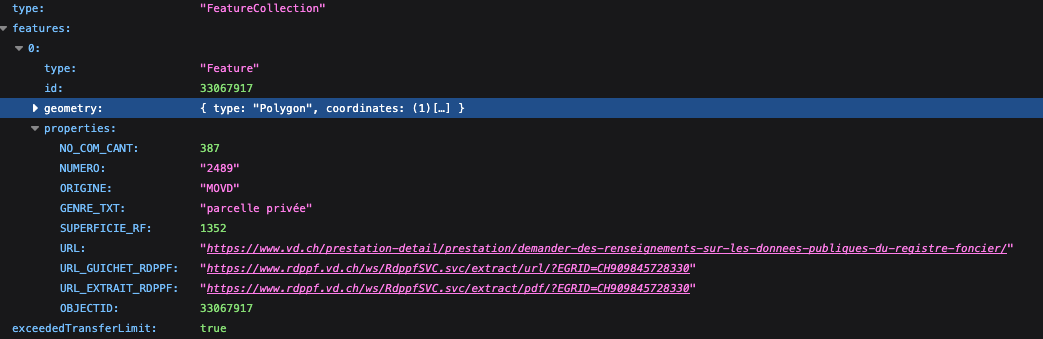



Astuces :
* il faut iterer dans le dictionnaire dict_biens_fonds
* pour chaque itération créer les attributs correspondant aux colonnes de la table dans le base de données PostgreSQL
* créer la géométrie. pour ce faire, regarder les fonctions suivantes:
    * https://postgis.net/docs/ST_GeomFromGeoJSON.html
    * https://postgis.net/docs/ST_SetSRID.html
    
    (il faudra utiliser ces deux fonctions pour indiquer à postGIS que nous lui transmettons une géométrie au format GeoJSON en 2056 (MN95)
* voici un exemple d'insertion de données à l'aide de psycopg2 


```
    cursor = conn.cursor()
    insert_feature_query = "Votre requête insert"
    try:
        cursor.execute(insert_feature_query) 
        conn.commit()
    except Exception as error:
        print(error)
        conn.rollback()
    cursor.close()
```
 


In [ ]:

cursor = conn.cursor()
for object_id, feature in dict_biens_fonds.items():


    geometry = feature["geometry"]

    print(feature)
    attributes = feature["properties"]
    no_cantonal = attributes["NO_COM_CANT"]
    numero = attributes["NUMERO"]
    genre = attributes["GENRE_TXT"]
    
    geometry_geojson = json.dumps(geometry)
    
    insert_feature_query = """
    INSERT INTO public.bf (no_cantonal, numero, genre, geom) 
    VALUES ('{no_cantonal}', '{numero}', '{genre}', ST_SetSRID(ST_GeomFromGeoJSON('{geom}'), 2056));
    """.format(no_cantonal=no_cantonal, numero=numero, genre=genre, geom=geometry_geojson)



    try:
        cursor.execute(insert_feature_query) 
        conn.commit()
    except Exception as error:
        print(f"Error inserting object ID {object_id}: {error}")
        conn.rollback()
        break
    



Et voilà, nos bien-fonds sont totalement chargés ! Bravo

<img src="images/bf_all.png" alt="drawing" width="800"/>



Pour teminer, nous fermons la connection à la base de données

In [ ]:
conn.close()